# 📊 Mental Health Analysis in Tech Industry

## 1. Introduction

Mental health is an important issue in the tech industry. Employees often face stress, anxiety, and depression due to workload and work environment.

This project analyzes a survey dataset to understand how different factors affect mental health among tech employees.

## 2. Problem Statement

Many employees in the tech industry face mental health issues but hesitate to seek treatment due to stigma and lack of support.

This project aims to identify the factors influencing mental health and suggest improvements.

## 3. Objective

- Analyze mental health conditions in tech industry
- Understand impact of workplace environment
- Study employee behavior towards treatment
- Provide insights for better workplace policies

## 4. Dataset Description

- Dataset: Mental Health in Tech Survey
- Records: 1259
- Features: 27 columns
- Includes:
  - Age
  - Gender
  - Work environment
  - Mental health treatment
  - Company support

## Import Libraries

In [12]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

## Loading Dataset

In [4]:
# Load dataset
df = pd.read_csv('/content/survey.csv')

# Display first 5 rows
df.head()

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


##Data Understanding

In [5]:
# Shape of dataset
df.shape

# Column names
df.columns

# Info
df.info()

# Missing values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Timestamp                  1259 non-null   object
 1   Age                        1259 non-null   int64 
 2   Gender                     1259 non-null   object
 3   Country                    1259 non-null   object
 4   state                      744 non-null    object
 5   self_employed              1241 non-null   object
 6   family_history             1259 non-null   object
 7   treatment                  1259 non-null   object
 8   work_interfere             995 non-null    object
 9   no_employees               1259 non-null   object
 10  remote_work                1259 non-null   object
 11  tech_company               1259 non-null   object
 12  benefits                   1259 non-null   object
 13  care_options               1259 non-null   object
 14  wellness

,0
Timestamp,0
Age,0
Gender,0
Country,0
state,515
self_employed,18
family_history,0
treatment,0
work_interfere,264
no_employees,0


##Data Cleaning

In [6]:
# Handling missing values
df = df.dropna()

# Cleaning Gender column
df['Gender'] = df['Gender'].str.lower()

df['Gender'] = df['Gender'].replace({
    'male': 'Male', 'm': 'Male',
    'female': 'Female', 'f': 'Female'
})

# Removing invalid age values
df = df[(df['Age'] > 0) & (df['Age'] < 100)]

df.head()

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
24,2014-08-27 11:36:48,33,Male,United States,CA,No,Yes,Yes,Rarely,26-100,...,Don't know,No,No,Yes,Yes,No,Yes,Don't know,No,Relatively new job. Ask again later
25,2014-08-27 11:37:08,35,Male,United States,TN,No,Yes,Yes,Sometimes,More than 1000,...,Very easy,Yes,No,Some of them,Yes,No,Yes,No,No,Sometimes I think about using drugs for my me...
33,2014-08-27 11:39:36,42,Male,United States,WA,No,Yes,Yes,Sometimes,26-100,...,Very easy,Maybe,No,Some of them,Some of them,Maybe,Yes,Don't know,No,I selected my current employer based on its po...
45,2014-08-27 11:43:36,38,Female,United States,TX,No,Yes,Yes,Sometimes,26-100,...,Somewhat easy,No,No,Some of them,Yes,No,No,Yes,No,Our health plan has covered my psychotherapy a...
49,2014-08-27 11:44:43,30,Male,United States,IL,No,Yes,Yes,Rarely,26-100,...,Don't know,Maybe,No,Some of them,Yes,No,No,Don't know,No,I just started a new job last week hence a lot...


##Feature Engineering

In [13]:
# Convert treatment to numeric
df['treatment'] = df['treatment'].map({'Yes': 1, 'No': 0})

# Fill missing work_interfere
df['work_interfere'] = df['work_interfere'].fillna('Unknown')


##📊  Exploratory Data Analysis (EDA)

###Age Distribution

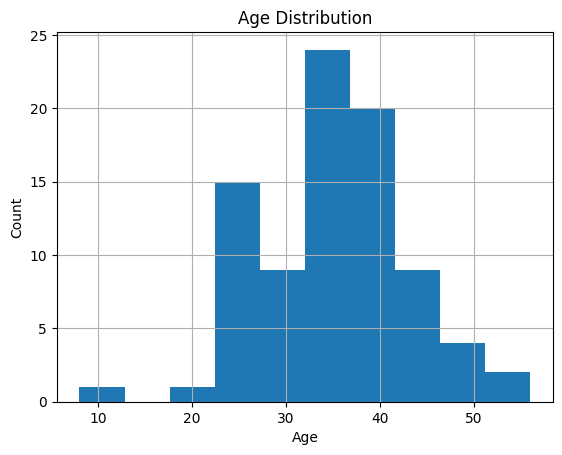

In [14]:
plt.figure()
df['Age'].hist()
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

###Gender Distribution

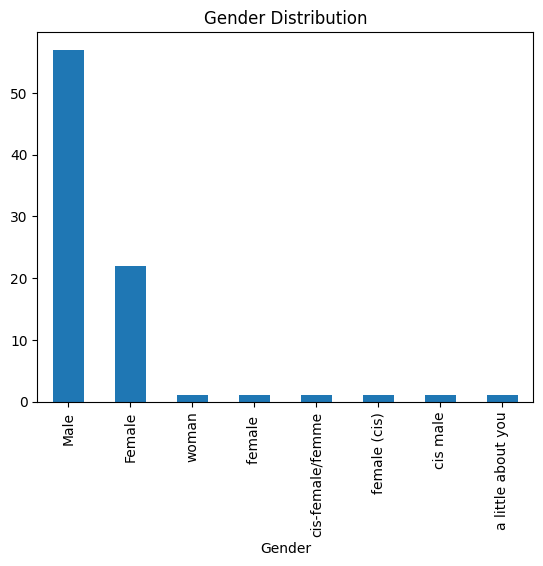

In [15]:
plt.figure()
df['Gender'].value_counts().plot(kind='bar')
plt.title("Gender Distribution")
plt.show()

###Treatment Count

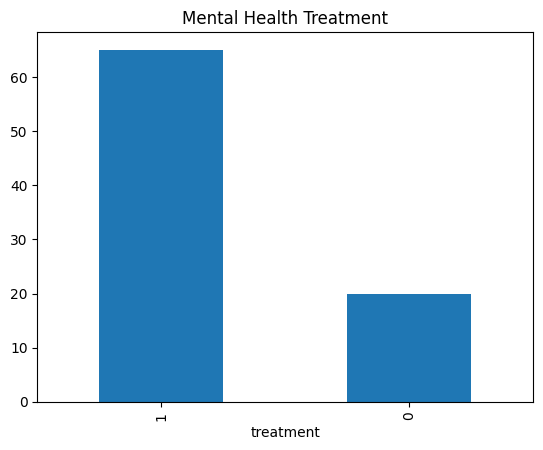

In [16]:
plt.figure()
df['treatment'].value_counts().plot(kind='bar')
plt.title("Mental Health Treatment")
plt.show()

###Work Interference

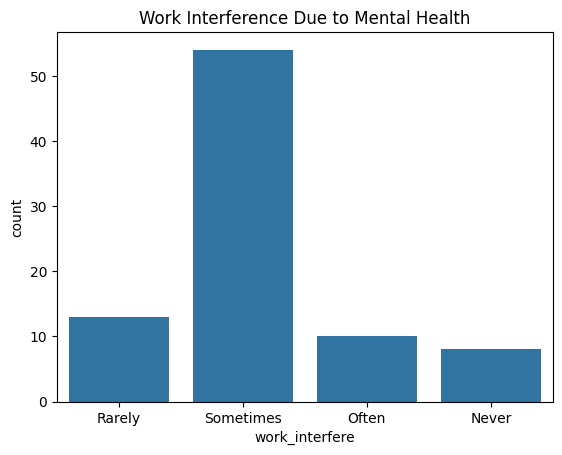

In [17]:
plt.figure()
sns.countplot(x='work_interfere', data=df)
plt.title("Work Interference Due to Mental Health")
plt.show()

##Model Building (Logistic Regression)

###Encoding

In [18]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

###Splitting Data

In [19]:
X = df.drop('treatment', axis=1)
y = df['treatment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

###Training Model

In [20]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

##Model Evaluation

In [21]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8235294117647058
              precision    recall  f1-score   support

           0       0.67      0.50      0.57         4
           1       0.86      0.92      0.89        13

    accuracy                           0.82        17
   macro avg       0.76      0.71      0.73        17
weighted avg       0.81      0.82      0.81        17



## 13. Key Insights

- Many employees hesitate to discuss mental health issues  
- Companies often lack proper support systems  
- Younger employees are more open to treatment  
- Work environment plays a major role in mental health  

## 14. Conclusion

Mental health is a significant concern in the tech industry.

Organizations should:
- Encourage open discussions  
- Provide mental health support  
- Improve workplace environment  

This will enhance employee well-being and productivity.

## 15. Future Scope

- Use advanced models like Random Forest and XGBoost  
- Build prediction systems for mental health risk  
- Create dashboards using Power BI or Tableau  
- Improve dataset quality  